In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [46]:
new_names=[
'word_freq_make',    
'word_freq_address', 
'word_freq_all',     
'word_freq_3d',      
'word_freq_our',     
'word_freq_over',    
'word_freq_remove',  
'word_freq_internet',
'word_freq_order',   
'word_freq_mail',    
'word_freq_receive', 
'word_freq_will',    
'word_freq_people',  
'word_freq_report',  
'word_freq_addresses',
'word_freq_free',    
'word_freq_business',
'word_freq_email',   
'word_freq_you',     
'word_freq_credit',  
'word_freq_your',    
'word_freq_font',    
'word_freq_000',     
'word_freq_money',   
'word_freq_hp'    ,  
'word_freq_hpl'    , 
'word_freq_george'  ,
'word_freq_650'     ,
'word_freq_lab'     ,
'word_freq_labs'    ,
'word_freq_telnet'  ,
'word_freq_857'     ,
'word_freq_data'    ,
'word_freq_415'     ,
'word_freq_85'      ,
'word_freq_technology',
'word_freq_1999'    ,
'word_freq_parts'   ,
'word_freq_pm'      ,
'word_freq_direct'  ,
'word_freq_cs'      ,
'word_freq_meeting' ,
'word_freq_original',
'word_freq_project' ,
'word_freq_re'      ,
'word_freq_edu'     ,
'word_freq_table'   ,
'word_freq_conference',
'char_freq_;'       ,
'char_freq_('       ,
'char_freq_['       ,
'char_freq_!'       ,
'char_freq_$'       ,
'char_freq_#'       ,
'capital_run_length_aver',
'capital_run_length_long',
'capital_run_length_total',
'spam'
]

In [47]:
df=pd.read_csv('spam.csv',header=None,names=new_names)
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_aver,capital_run_length_long,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [52]:
print(df.isnull().sum().sum())

0


In [55]:

print("\nSpam Counts (1 = Spam, 0 = Not Spam):")
print(df['spam'].value_counts())


Spam Counts (1 = Spam, 0 = Not Spam):
spam
0    2788
1    1813
Name: count, dtype: int64


C:\Users\krish\AppData\Local\Temp\ipykernel_17428\2205555329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='spam', palette='coolwarm')


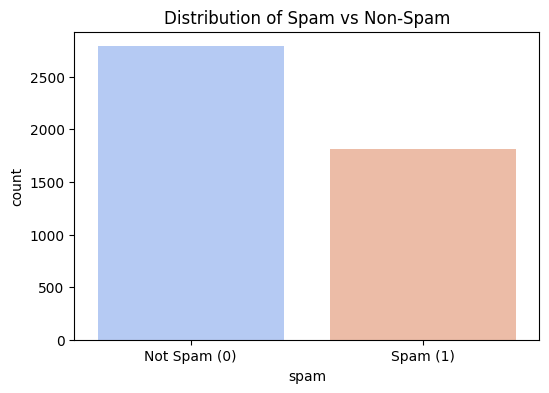

In [57]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='spam', palette='coolwarm')
plt.title('Distribution of Spam vs Non-Spam')
plt.xticks([0, 1], ['Not Spam (0)', 'Spam (1)'])
plt.show()

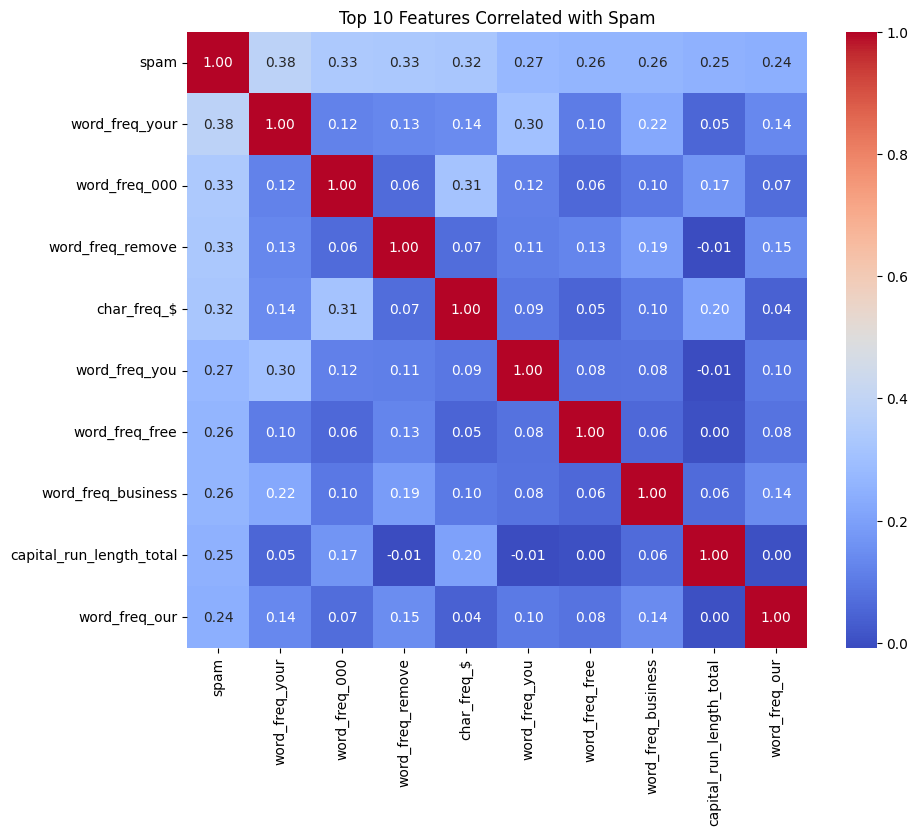

In [61]:
plt.figure(figsize=(10,8))
corr_matrix=df.corr()
k=10
top_features=corr_matrix.nlargest(k,'spam')['spam'].index
sns.heatmap(df[top_features].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Top 10 Features Correlated with Spam')
plt.show()

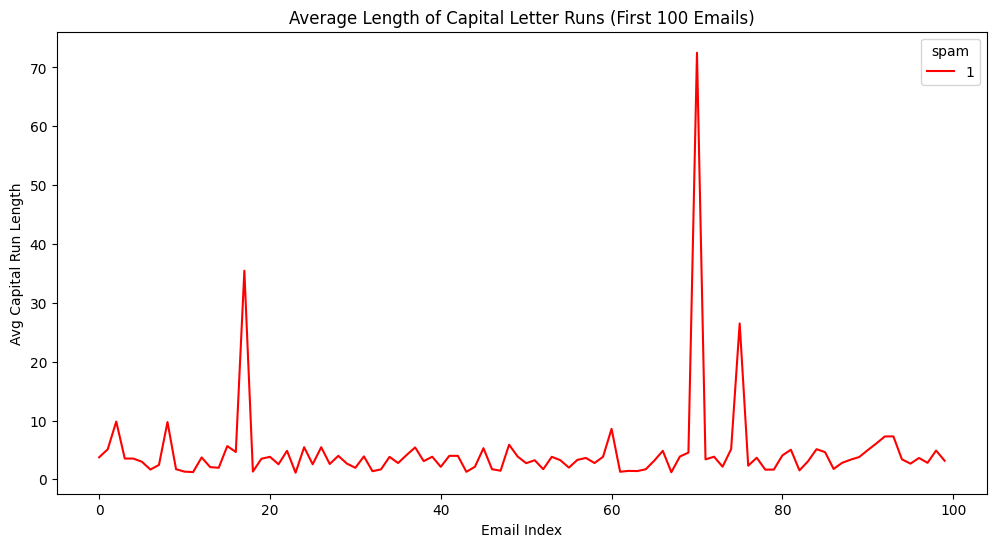

In [64]:
plt.figure(figsize=(12, 6))

subset = df.iloc[:100]

sns.lineplot(data=subset, x=subset.index, y='capital_run_length_aver', hue='spam', palette={0:'blue', 1:'red'})

plt.title('Average Length of Capital Letter Runs (First 100 Emails)')
plt.xlabel('Email Index')
plt.ylabel('Avg Capital Run Length')
plt.show()

<Figure size 1000x800 with 0 Axes>

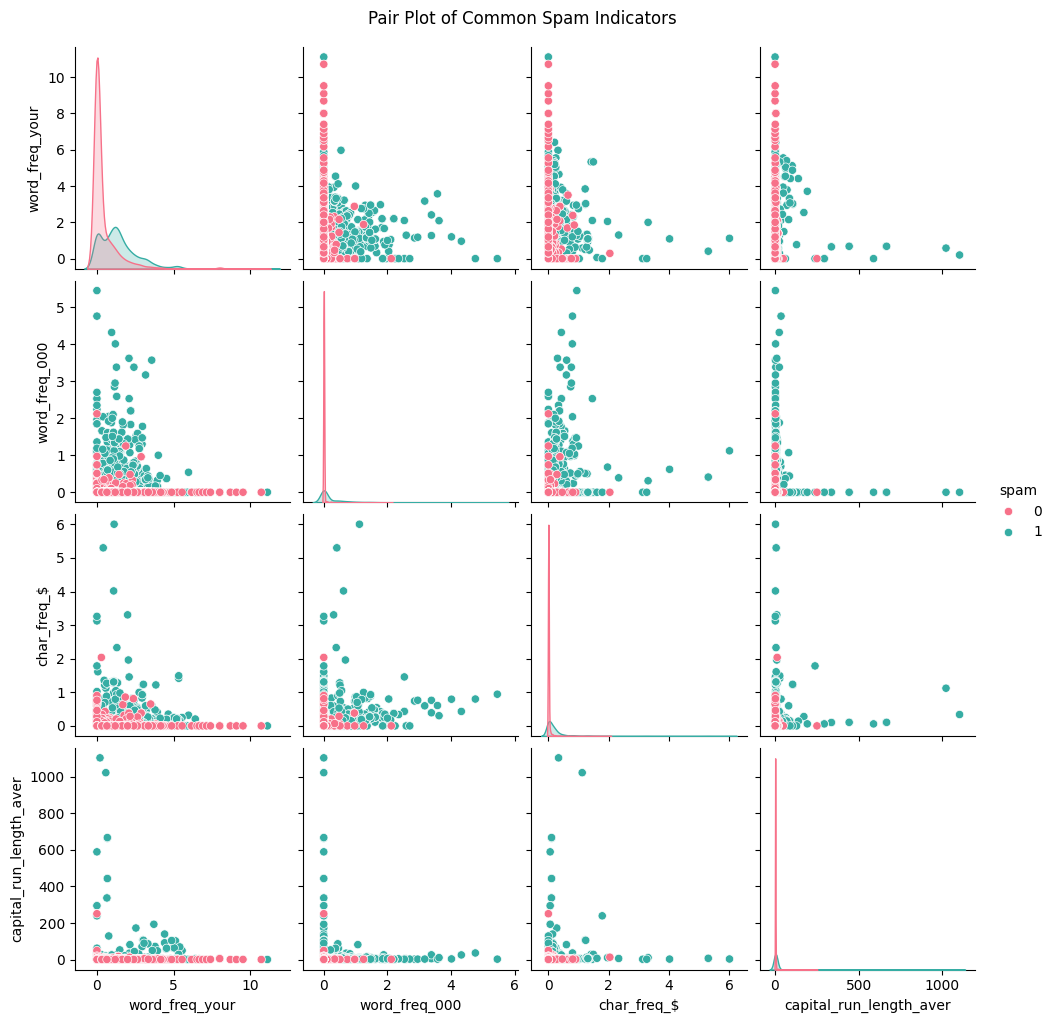

In [66]:
selected_cols = ['word_freq_your', 'word_freq_000', 'char_freq_$', 'capital_run_length_aver', 'spam']

plt.figure(figsize=(10, 8))
sns.pairplot(df[selected_cols], hue='spam', diag_kind='kde', palette='husl')
plt.suptitle('Pair Plot of Common Spam Indicators', y=1.02)
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_17428\824902335.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='spam', y='char_freq_$', palette='Set2')


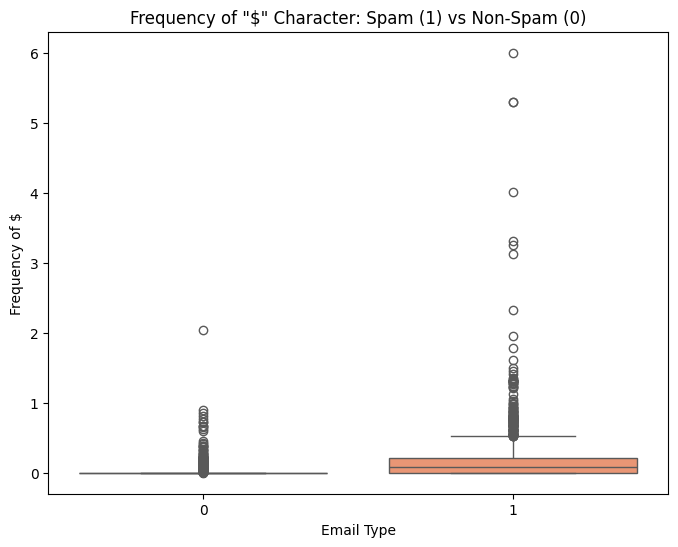

C:\Users\krish\AppData\Local\Temp\ipykernel_17428\824902335.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='spam', y='capital_run_length_aver', palette='coolwarm')


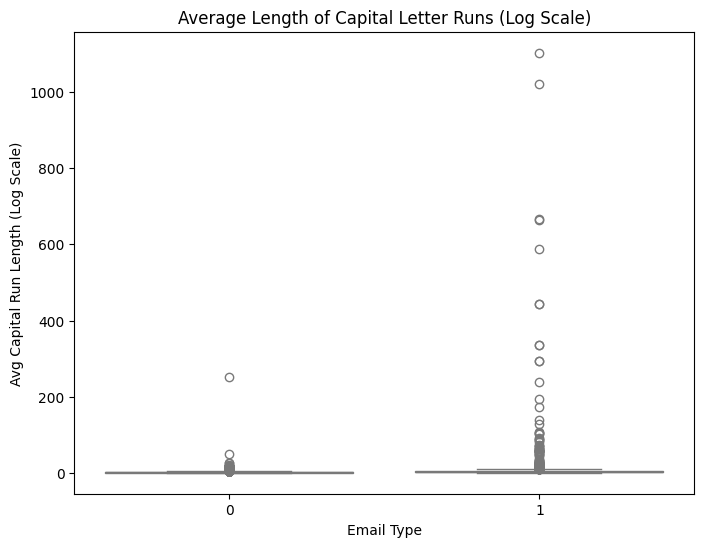

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Comparison of Dollar Sign Frequency ($)
plt.figure(figsize=(8, 6))

# We use 'sym=""' to hide the thousands of outlier points if you want a cleaner look,
# but usually, seeing the outliers is the point!
sns.boxplot(data=df, x='spam', y='char_freq_$', palette='Set2')

plt.title('Frequency of "$" Character: Spam (1) vs Non-Spam (0)')
plt.xlabel('Email Type')
plt.ylabel('Frequency of $')
plt.show()

# 2. Comparison of Capital Run Length (The "SHOUTING" metric)
# Since outliers are huge here, we use a Log Scale to make it readable
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='spam', y='capital_run_length_aver', palette='coolwarm')


plt.title('Average Length of Capital Letter Runs (Log Scale)')
plt.xlabel('Email Type')
plt.ylabel('Avg Capital Run Length (Log Scale)')
plt.show()

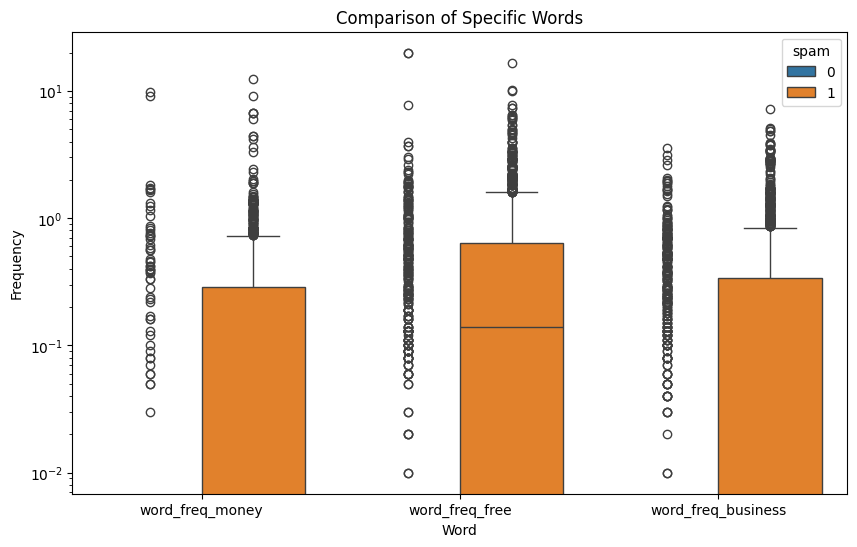

In [73]:
features_to_plot = ['word_freq_money', 'word_freq_free', 'word_freq_business']


df_melted = df.melt(id_vars='spam', value_vars=features_to_plot, var_name='Word', value_name='Frequency')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Word', y='Frequency', hue='spam')
plt.title('Comparison of Specific Words')
plt.yscale('log') 
plt.show()